In [24]:
import os, json
import numpy as np
import pandas as pd

In [25]:
INPUT_XLSX          = "process_data_5.xlsx"   # đổi nếu bạn dùng file khác
OUTPUT_XLSX         = "data_final.xlsx"
MIN_W, MIN_H        = 100, 100    # bỏ ảnh quá nhỏ (đặt None để bỏ qua), vd: MIN_W=None, MIN_H=None
DROP_MISSING_FILES  = True        # loại ảnh không còn tồn tại ở path
DROP_INVALID_LABELS = True        # loại dòng có is_duplicate không thuộc {0,1}, nếu False sẽ tự chuẩn hoá
DROP_SINGLETONS     = False       # True: loại ảnh cluster_id=-1 (đơn lẻ)
FRONT_COLS_ORDER    = ["path","category","category_id","is_duplicate","cluster_id","cluster_size","width","height","aspect_ratio"]

In [26]:
df = pd.read_excel(INPUT_XLSX)
print(f"📂 Loaded {INPUT_XLSX} | shape={df.shape}")

# Bắt buộc có path
if "path" not in df.columns:
    raise ValueError(f"{INPUT_XLSX} thiếu cột 'path'!")

📂 Loaded process_data_5.xlsx | shape=(500, 235)


In [27]:
# Chuẩn hoá path & loại rỗng
df["path"] = df["path"].astype(str).str.strip()
before = len(df)
df = df[df["path"].str.len() > 0].copy()
print(f"🧹 Loại {before - len(df)} dòng path rỗng")

# loại file mất
if DROP_MISSING_FILES:
    exists_mask = df["path"].apply(lambda p: os.path.exists(p))
    before = len(df)
    df = df[exists_mask].copy()
    print(f"🧹 Loại {before - len(df)} dòng do file không tồn tại")

# bỏ ảnh quá nhỏ nếu có width/height
if ("width" in df.columns) and ("height" in df.columns) and (MIN_W is not None) and (MIN_H is not None):
    before = len(df)
    df = df[(df["width"]>=MIN_W) & (df["height"]>=MIN_H)]
    print(f"🧹 Loại {before - len(df)} ảnh nhỏ hơn {MIN_W}x{MIN_H}")

# Chuẩn hoá is_duplicate
if "is_duplicate" not in df.columns:
    df["is_duplicate"] = 0
else:
    # chuyển về {0,1}
    df["is_duplicate"] = (
        df["is_duplicate"]
        .apply(lambda x: str(x).strip().lower())
        .replace({"true": "1", "false": "0", "yes": "1", "no": "0"})
        .replace({"nan": "0", "none": "0", "": "0"})
        .astype(float)
        .astype(int)
        .clip(0,1)
    )

# loại các dòng có nhãn không hợp lệ (sau chuẩn hoá hầu như không còn)
if DROP_INVALID_LABELS:
    before = len(df)
    df = df[df["is_duplicate"].isin([0,1])]
    print(f"🧹 Loại {before - len(df)} dòng nhãn không hợp lệ")

# Reindex cluster_id (0..K-1) & tính cluster_size nếu thiếu
if "cluster_id" in df.columns:
    # chuyển kiểu số, -1 cho NaN
    df["cluster_id"] = pd.to_numeric(df["cluster_id"], errors="coerce").fillna(-1).astype(int)
    unique_clusters = sorted([c for c in df["cluster_id"].unique() if c != -1])
    map_id = {old: new for new, old in enumerate(unique_clusters)}
    df["cluster_id"] = df["cluster_id"].map(lambda x: map_id.get(x, -1))
else:
    df["cluster_id"] = -1

# (Tuỳ chọn) drop singletons
if DROP_SINGLETONS:
    before = len(df)
    df = df[df["cluster_id"] != -1].copy()
    print(f"🧹 Loại {before - len(df)} dòng singleton (cluster_id=-1)")

# cluster_size
df["cluster_size"] = (
    df.groupby("cluster_id")["cluster_id"].transform("size").where(df["cluster_id"]!=-1, 1)
)

🧹 Loại 0 dòng path rỗng
🧹 Loại 0 dòng do file không tồn tại
🧹 Loại 0 ảnh nhỏ hơn 100x100
🧹 Loại 0 dòng nhãn không hợp lệ


In [28]:
# Sắp thứ tự cột
front = [c for c in FRONT_COLS_ORDER if c in df.columns]
others = [c for c in df.columns if c not in front]
df_clean = df[front + others].reset_index(drop=True)

# Lưu
df_clean.to_excel(OUTPUT_XLSX, index=False)
print(f"✅ Saved: {OUTPUT_XLSX} | shape={df_clean.shape}")

# Thống kê
print("\n📊 Stats:")
if "category_id" in df_clean.columns:
    print("  - Số category:", df_clean["category_id"].nunique())
print("  - Tổng ảnh:", len(df_clean))
print("  - is_duplicate=1:", int((df_clean['is_duplicate']==1).sum()))
print("  - is_duplicate=0:", int((df_clean['is_duplicate']==0).sum()))
if "cluster_id" in df_clean.columns:
    n_clusters = (df_clean["cluster_id"]!=-1).sum()
    print("  - Ảnh thuộc cluster:", n_clusters)

✅ Saved: data_final.xlsx | shape=(500, 235)

📊 Stats:
  - Số category: 5
  - Tổng ảnh: 500
  - is_duplicate=1: 175
  - is_duplicate=0: 325
  - Ảnh thuộc cluster: 175


In [29]:
import matplotlib.pyplot as plt

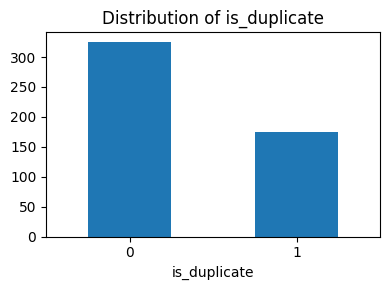

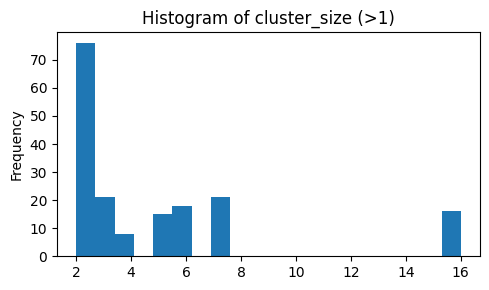

In [30]:
dfc = pd.read_excel("data_final.xlsx")

# is_duplicate
if "is_duplicate" in dfc.columns:
    plt.figure(figsize=(4,3))
    dfc["is_duplicate"].value_counts().sort_index().plot(kind="bar")
    plt.title("Distribution of is_duplicate")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# cluster_size
if "cluster_size" in dfc.columns:
    plt.figure(figsize=(5,3))
    (dfc.loc[dfc["cluster_size"]>1,"cluster_size"]
        .clip(upper=20)  # gộp >20 vào 20 để nhìn rõ
        .plot(kind="hist", bins=20))
    plt.title("Histogram of cluster_size (>1)")
    plt.tight_layout()
    plt.show()